In [18]:
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import pandas as pd
import os
from pathlib import Path
import geopandas as gpd
import contextily as ctx
import io, zipfile, requests
import shapely

import folium
import mapclassify

In [ ]:
pois_agg = pd.read_csv('../data/chicago_pois_agg.csv')
pois_agg.head()

,h3_index,poi_count,count_poi_types,poi_type_list,poi_list
0,8826641917fffff,8,5,"place_of_worship, bicycle_rental, school, bar,...","Saint Columba Roman Catholic Church, Ave O & 1..."
1,882664191dfffff,5,2,"shelter, information, shelter, shelter, shelter","Picnic Shelter #1, Visitors Center, Picnic She..."
2,8826641927fffff,2,2,"artwork, fire_station",Chicago Fire Department Engine Company 80
3,8826641931fffff,1,1,place_of_worship,Lebanon Lutheran Church
4,8826641939fffff,2,2,"bicycle_rental, school","Torrence Ave & 126th Pl, Virgil Grissom Elemen..."


In [ ]:
def get_hexagon_grid(h3_indices):
    """
    Convert an iterable of H3 cell IDs into a GeoDataFrame of hexagon polygons.

    Parameters
    ----------
    h3_indices : iterable of str
        H3 cell IDs (e.g. from pois_agg['h3_index']).

    Returns
    -------
    GeoDataFrame with columns 'h3_index' and 'geometry', CRS EPSG:4326.
    """
    def _to_polygon(cell):
        # h3-py v4: cell_to_boundary returns [(lat, lng), ...]
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    h3_list = list(h3_indices)
    geometries = [_to_polygon(cell) for cell in h3_list]
    return gpd.GeoDataFrame({'h3_index': h3_list, 'geometry': geometries}, crs='EPSG:4326')

def create_choropleth_plot(gdf,value_col,cmap='YlOrRd',figsize=(11, 14),k=7,):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain 'geometry' and `value_col`. CRS EPSG:4326.
    value_col : str
        Column used to colour hexagons.
    title : str
        Figure title.
    cmap : str
        Matplotlib colour map name.
    figsize : tuple
        Figure size in inches.
    k : int
        Number of quantile classes for the colour scheme.

    Returns
    -------
    fig, ax
    """
    title='POI count per H3 hexagon'
    fig, ax = plt.subplots(figsize=figsize)

    gdf_web = gdf.to_crs(epsg=3857)
    gdf_web.plot(
        ax=ax,
        column=value_col,
        cmap=cmap,
        scheme='quantiles',
        k=k,
        edgecolor='none',
        alpha=0.8,
        legend=True,
        legend_kwds=dict(
            title=value_col.replace('_', ' ').title(),
            loc='lower right',
            fontsize=8,
            title_fontsize=9,
        ),
        missing_kwds=dict(color='lightgrey', label='No data'),
    )

    # Chicago community area outlines as spatial reference
    ca_path = Path('..') / 'data' / 'chicago_community_areas.gpkg'
    if ca_path.exists():
        ca = gpd.read_file(ca_path).to_crs(epsg=3857)
        ca.boundary.plot(ax=ax, color='#333', linewidth=0.8, alpha=0.6)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig, ax

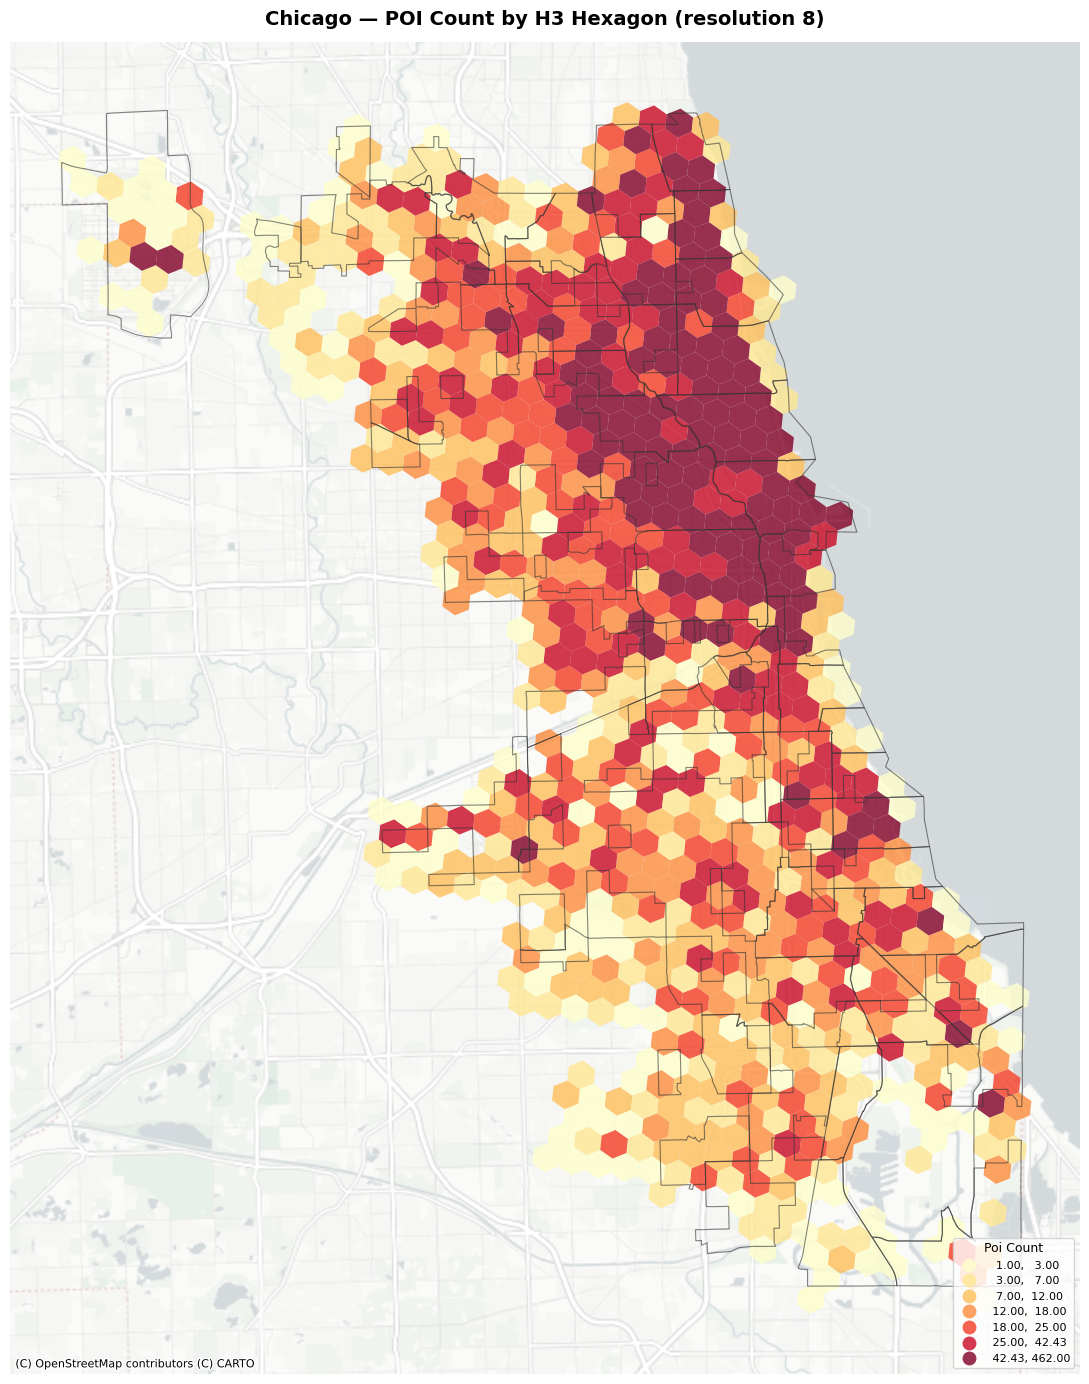

In [ ]:
# Build hexagon geometries from the h3_index values already in pois_agg
hex_gdf = get_hexagon_grid(pois_agg['h3_index'])
hex_gdf = hex_gdf.merge(pois_agg, on='h3_index', how='left')

fig, ax = create_choropleth_plot(
    hex_gdf,
    value_col='poi_count',
    title='Chicago — POI Count by H3 Hexagon (resolution 8)',
)
plt.show()